# Cálculo de sistemas lineales: estables, inestables, asintóticamente estables, etc.

*(Traducción a Python del script `lineal.m`, usando `numpy`, `scipy` y `matplotlib`)*

El `.m` original define una batería de sistemas lineales $\dot x = Ax$ en el plano, cada uno representando un caso distinto de clasificación según sus autovalores (nodo estable, nodo inestable, foco, silla, centro, autovalores repetidos, autovalor en el origen...), y dibuja el retrato de fases de uno de ellos (`circular`) barriendo una malla de condiciones iniciales.

En MATLAB cada sistema es una función `.m` local distinta (`real_menos`, `real_mas`, `silla`, ...) y para cambiar de un sistema a otro hay que editar a mano el nombre de la función pasado a `ode45` (`@circular` en el script original). En Python, en vez de definir una función por sistema, agrupamos todas las matrices $A$ en un diccionario y usamos **una sola** función genérica $\dot x = Ax$ — así, para cambiar de sistema, solo hay que cambiar la clave del diccionario, sin tocar ninguna función.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Sistemas lineales de ejemplo

Cada matriz representa un caso distinto de clasificación de sistemas lineales 2D según sus autovalores. Puedes comprobarlo tú mismo calculando `np.linalg.eigvals(A)` para cada una.

In [2]:
matrices = {
    'real_menos': np.array([[-3, -2], [1, 0]]),    # autovalores reales negativos (nodo estable)
    'real_mas':   np.array([[3, -2], [1, 0]]),     # autovalores reales positivos (nodo inestable)
    'cpl_mas':    np.array([[1, -3], [4, 2]]),     # complejos conjugados, parte real positiva (foco inestable)
    'cpl_menos':  np.array([[-1, -3], [4, -2]]),   # complejos conjugados, parte real negativa (foco estable)
    'silla':      np.array([[0, 1], [1, 0]]),      # un autovalor positivo, otro negativo (punto de silla)
    'imaginario': np.array([[-1, -3], [4, 1]]),    # imaginarios puros (centro)
    'repetidosp': np.array([[0, 1], [-1, 2]]),     # autovalor repetido positivo
    'repetidosm': np.array([[-2, 1], [-1, 0]]),    # autovalor repetido negativo
    'uncero':     np.array([[-3, 1], [3, -1]]),    # un autovalor en el origen
    'unceroi':    np.array([[1, 1], [1, 1]]),      # un autovalor en el origen (inestable)
    'iguales':    np.array([[-1, 0], [0, -1]]),    # autovalores reales negativos iguales (nodo estrella)
    'circular':   np.array([[0, -3.316624790355399],
                            [3.316624790355399, 0]]),  # imaginarios puros (orbita circular)
}

El caso `ceros` se construye aparte porque en el `.m` original se obtiene mediante un cambio de base (matriz de rotación $R$) sobre una matriz $A$ con un único autovalor cero de multiplicidad geométrica 1 (bloque de Jordan no diagonalizable).

In [3]:
R = np.array([
    [np.cos(np.pi/4), -np.sin(np.pi/4)],
    [np.sin(np.pi/4),  np.cos(np.pi/4)]
])
A_ceros = np.array([[0, 0], [1, 0]])
matrices['ceros'] = R @ A_ceros @ np.linalg.inv(R)   # cambio de base: R A R^-1

Podemos comprobar los autovalores de todos los sistemas de un vistazo, para verificar que cada nombre describe correctamente su caso,

In [4]:
for nombre, A in matrices.items():
    print(f'{nombre:12s} autovalores: {np.linalg.eigvals(A)}')

real_menos   autovalores: [-2. -1.]
real_mas     autovalores: [2. 1.]
cpl_mas      autovalores: [1.5+3.4278j 1.5-3.4278j]
cpl_menos    autovalores: [-1.5+3.4278j -1.5-3.4278j]
silla        autovalores: [ 1. -1.]
imaginario   autovalores: [0.+3.3166j 0.-3.3166j]
repetidosp   autovalores: [1. 1.]
repetidosm   autovalores: [-1. -1.]
uncero       autovalores: [-4.  0.]
unceroi      autovalores: [2. 0.]
iguales      autovalores: [-1. -1.]
circular     autovalores: [0.+3.3166j 0.-3.3166j]
ceros        autovalores: [0. 0.]


## Sistema genérico y retrato de fases

Definimos una única función para $\dot x = Ax$, válida para cualquiera de las matrices anteriores (ver `sistema_lineal` a continuación).

In [5]:
def sistema_lineal(t, x, A):
    """Sistema lineal generico: xdot = A @ x."""
    return A @ x

Elegimos el sistema a representar cambiando simplemente esta variable — en el `.m` original, el sistema activo era `circular` (así estaba escrito en la llamada a `ode45(@circular,...)`), así que empezamos igual.

In [6]:
nombre_sistema = 'circular'   # cambia esto por cualquier clave de 'matrices' para explorar otro caso
A = matrices[nombre_sistema]

xm = np.arange(-1, 1 + 0.001, 0.2)   # malla de condiciones iniciales (equivalente a -1:0.2:1)
t_span = [0, 1]

Barremos la malla de condiciones iniciales, integramos cada trayectoria y la dibujamos, junto con el punto de partida (`.`) y el punto de llegada (`x`), igual que en el `.m` original.

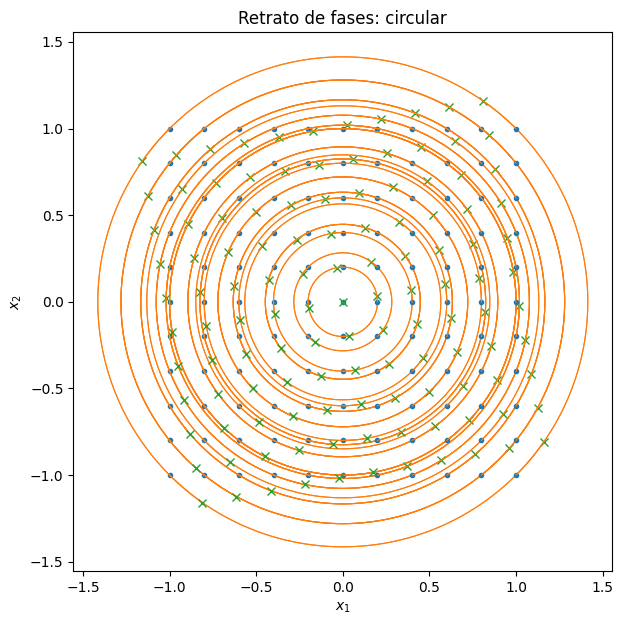

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

for i in xm:
    for j in xm:
        x0 = [i, j]
        sol = solve_ivp(sistema_lineal, t_span, x0, args=(A,), max_step=0.01)

        ax.plot(x0[0], x0[1], '.', color='tab:blue')             # condicion inicial
        ax.plot(sol.y[0], sol.y[1], color='tab:orange', linewidth=0.8)  # trayectoria
        ax.plot(sol.y[0, -1], sol.y[1, -1], 'x', color='tab:green')     # punto final

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'Retrato de fases: {nombre_sistema}')
ax.set_aspect('equal')
plt.show()

Para ver el retrato de fases de cualquier otro caso, basta con volver a ejecutar las dos últimas celdas cambiando `nombre_sistema` por cualquiera de las claves del diccionario `matrices` (por ejemplo `'silla'`, `'iguales'`, `'imaginario'`...).